<a href="https://colab.research.google.com/github/aryanp2107/100-ML-Projects/blob/main/Day58_GANs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import time
from IPython.display import clear_output

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers

import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


GAN Intuition

In [ ]:
"""

Two neural networks playing a game:

GENERATOR (G) - The Counterfeiter
  • Input: Random noise z
  • Output: Fake image
  • Goal: Create images that fool the discriminator

DISCRIMINATOR (D) - The Detective
  • Input: Real or fake image
  • Output: Probability (real vs fake)
  • Goal: Correctly identify fakes

Training:
  • D tries to maximize: Detect real as real, fake as fake
  • G tries to minimize: Make D think fakes are real
  • Over time: G gets better at faking, D gets better at detecting
  • Equilibrium: G produces realistic images!

Loss function - In practice we use Binary Cross Entropy:
  D_loss = BCE(D(real), 1) + BCE(D(fake), 0)
  G_loss = BCE(D(fake), 1)  # Want D to output 1 for fakes

"""

In [2]:
!pip install kaggle -q

In [3]:
!kaggle datasets download -d splcher/animefacedataset -q
!unzip -q animefacedataset.zip -d anime_faces

print("Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/splcher/animefacedataset
License(s): DbCL-1.0
Dataset downloaded!


In [4]:
#checking the dataset
import glob

image_paths = glob.glob('anime_faces/**/*.png', recursive=True) + \
              glob.glob('anime_faces/**/*.jpg', recursive=True)

print(f"FOund  {len(image_paths)} images")

if len(image_paths) > 0:
  print(f"Sample path: {image_paths[0]}")

FOund  63565 images
Sample path: anime_faces/images/37738_2012.jpg


In [5]:
from numpy.random.mtrand import f
IMG_SIZE = 64
BATCH_SIZE =  64
LATENT_DIM = 100

print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"batch size: {BATCH_SIZE}")
print(f"latent dim: {LATENT_DIM}")

Image size: 64x64
batch size: 64
latent dim: 100


In [8]:
def load_and_preprocess(path):
  """ Loading the images ane normalizing ti [-1, 1]"""
  img = tf.io.read_file(path)
  img = tf.image.decode_image(img, channels=3, expand_animations=False)
  img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
  img = (img  - 127.5) / 127.5
  return img

dataset = tf.data.Dataset.from_tensor_slices(image_paths)
dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.shuffle(10000)
dataset = dataset.batch(BATCH_SIZE, drop_remainder=True)
dataset = dataset.prefetch(tf.data.AUTOTUNE)

print(f"Dataset created with {len(image_paths)} images")

Dataset created with 63565 images


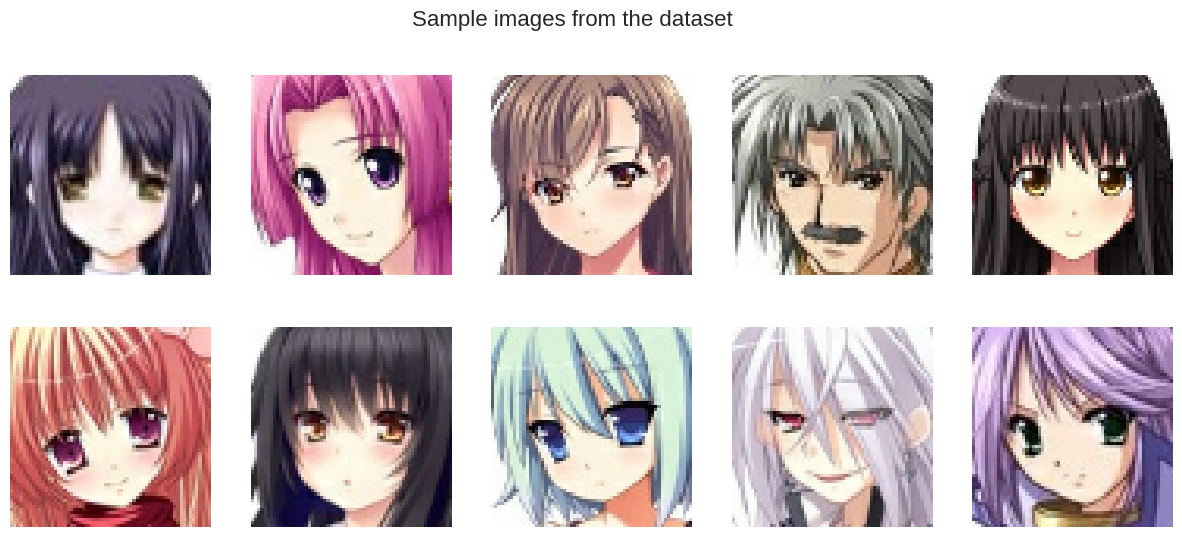

In [10]:
sample_batch = next(iter(dataset))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    #denormalize from [-1, 1] to [0, 1]
    img = (sample_batch[i].numpy() + 1) / 2
    ax.imshow(img)
    ax.axis('off')

plt.suptitle('Sample images from the dataset', fontsize=16)
plt.show()

DCGAN Architecture

In [12]:
"""

DCGAN (Deep Convolutional Generative Adversarial Network) is a class of convolutional
neural networks used for unsupervised learning and, specifically, for generating high-quality synthetic images.
Introduced by Radford et al. in 2015, it improves upon traditional GANs by establishing a set of architectural
constraints—primarily using convolutional layers instead of fully connected layers—to stabilize training and enhance the quality of generated images

1. Use strided convolutions (no pooling)
2. Batch normalization in both G and D
3. Remove fully connected layers (except input/output)
4. ReLU in Generator (except output: Tanh)
5. LeakyReLU in Discriminator

GENERATOR:
  z (100,) → Dense → Reshape → ConvT → ConvT → ConvT → ConvT → Image (64,64,3)

  Noise → 4×4×512 → 8×8×256 → 16×16×128 → 32×32×64 → 64×64×3

DISCRIMINATOR:
  Image (64,64,3) → Conv → Conv → Conv → Conv → Flatten → Dense → Real/Fake

  64×64×3 → 32×32×64 → 16×16×128 → 8×8×256 → 4×4×512 → 1

"""

'\n\n'

Building the Generator


In [24]:
def build_generator(latent_dim=100):
  """

  Generator: noise -> image
  uses transposed convolutionals to upsample the latent space

  """

  model = models.Sequential(name='generator')

  #Foundation: 4x4x512
  model.add(layers.Dense(4*4*512, use_bias=False, input_shape=(latent_dim,)))
  model.add(layers.BatchNormalization())
  model.add(layers.ReLU())
  model.add(layers.Reshape((4, 4, 512)))

  #Upsample: 4x4 -> 8x8
  model.add(layers.Conv2DTranspose(256, (5, 5), strides=(2, 2), padding='same', use_bias=False))
  model.add(layers.BatchNormalization())
  model.add(layers.ReLU())

  #Upsample: 8x8 -> 16x16
  model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
  model.add(layers.BatchNormalization())
  model.add(layers.ReLU())

  #upsample: 16x16 -> 32x32 (Adjusted filters to 64 as per architecture, previously 128)
  model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
  model.add(layers.BatchNormalization())
  model.add(layers.ReLU())

  #Output: 32x32 -> 64x64 (This becomes the final output layer, filters set to 3)
  model.add(layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))

  return model

generator = build_generator(LATENT_DIM)
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 8192)           │       819,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 8192)           │        32,768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_15 (ReLU)                 │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_13             │ (None, 8, 8, 256)      │     3,276,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_16 (ReLU)                 │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_14             │ (None, 16, 16, 128)    │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_17 (ReLU)                 │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_15             │ (None, 32, 32, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_18 (ReLU)                 │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_16             │ (None, 64, 64, 3)      │         4,800 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,159,360 (19.68 MB)

 Trainable params: 5,142,080 (19.62 MB)

 Non-trainable params: 17,280 (67.50 KB)

Input noise shape: (1, 100)
Generated image shape: (1, 64, 64, 3)


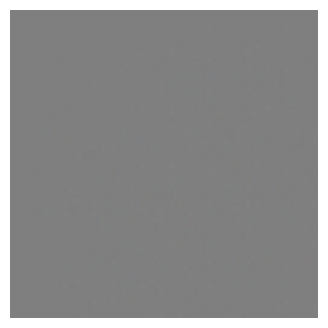

In [25]:
#Testing the generator with some random noise
noise = tf.random.normal([1, LATENT_DIM])
generated_image = generator(noise, training=False)

print(f"Input noise shape: {noise.shape}")
print(f"Generated image shape: {generated_image.shape}")

plt.figure(figsize=(4, 4))
plt.imshow((generated_image[0].numpy() + 1) / 2)
plt.axis('off')
plt.show()

Buidling the Discriminator

In [26]:
def build_discriminator():
  """
  Discriminator: image -> real/fake probability
  uses strided convolutions to downsample
  """
  model = models.Sequential(name='discriminator')

  #64x64 -> 32x32
  model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[64, 64, 3]))
  model.add(layers.LeakyReLU(0.2))
  model.add(layers.Dropout(0.3))

  #32x32 -> 16x16
  model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
  model.add(layers.BatchNormalization())
  model.add(layers.LeakyReLU(0.2))
  model.add(layers.Dropout(0.3))

  #16x16 -> 8x8
  model.add(layers.Conv2D(256, (5, 5), strides=(2, 2), padding='same'))
  model.add(layers.BatchNormalization())
  model.add(layers.LeakyReLU(0.2))
  model.add(layers.Dropout(0.3))

  #8x8 -> 4x4
  model.add(layers.Conv2D(512, (5, 5), strides=(2, 2), padding='same'))
  model.add(layers.BatchNormalization())
  model.add(layers.LeakyReLU(0.2))
  model.add(layers.Dropout(0.3))

  #output
  model.add(layers.Flatten())
  model.add(layers.Dense(1))

  #dont use signmoid

  return model

discriminator = build_discriminator()
discriminator.summary()

Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 4, 4, 512)      │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,318,337 (16.47 MB)

 Trainable params: 4,316,545 (16.47 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [27]:
# Test discriminator
decision = discriminator(generated_image, training=False)

print(f"Input image shape: {generated_image.shape}")
print(f"Discriminator output: {decision.numpy()}")
print(f"(Negative = fake, Positive = real)")

Input image shape: (1, 64, 64, 3)
Discriminator output: [[0.00014925]]
(Negative = fake, Positive = real)


The Loss Functions

In [28]:
cross_entropy = keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
  """
    D wants:
      - real_output → 1 (identify real as real)
      - fake_output → 0 (identify fake as fake)
    """
  real_loss = cross_entropy(tf.ones_like(real_output), real_output)
  fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
  total_loss = real_loss + fake_loss
  return total_loss

def generator_loss(fake_output):
  """
    G wants:
      - fake_output → 1 (identify fake as real)
    """
  return cross_entropy(tf.ones_like(fake_output), fake_output)

print("THE LOSS FUNCTIONS ARE READY!")

THE LOSS FUNCTIONS ARE READY!


In [29]:
generator_optimizers = optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator_optimizers = optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

Training Loop

In [36]:
SEED_NOISE = tf.random.normal([16, LATENT_DIM])

@tf.function
def train_step(images):
  """ A single training step for both the G and D """
  noise = tf.random.normal([BATCH_SIZE, LATENT_DIM])

  with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
    #Generate fake images
    generated_images = generator(noise, training=True)

    #Discriminator predictions
    real_output = discriminator(images, training=True)
    fake_output = discriminator(generated_images, training=True)

    #Calculating the losses
    gen_loss = generator_loss(fake_output)
    disc_loss = discriminator_loss(real_output, fake_output)

  #Calculating the gradients
  gen_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
  disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

  #Applying the gradients
  generator_optimizers.apply_gradients(zip(gen_gradients, generator.trainable_variables))
  discriminator_optimizers.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))

  return gen_loss, disc_loss

In [42]:
def generate_and_train_images(model, epoch, noise):
  predictions = model(noise, training=False)

  fig, axes = plt.subplots(4, 4, figsize=(8, 8))

  for i, ax in enumerate(axes.flatten()):
    img = (predictions[i].numpy() + 1) / 2
    img = np.clip(img, 0.0, 1.0) # Corrected np.clip usage
    ax.imshow(img)
    ax.axis('off')

  plt.suptitle(f'Epoch {epoch}', fontsize=16)
  plt.savefig(f'generated_epoch_{epoch:04d}.png')
  plt.show()

Training the GAN...
Epoch   1/50 | Gen Loss: 4.3598 | Disc Loss: 0.3303 | Time: 153.07s
Epoch   5/50 | Gen Loss: 4.4123 | Disc Loss: 0.3185 | Time: 151.95s
Epoch  10/50 | Gen Loss: 4.7190 | Disc Loss: 0.2965 | Time: 152.62s


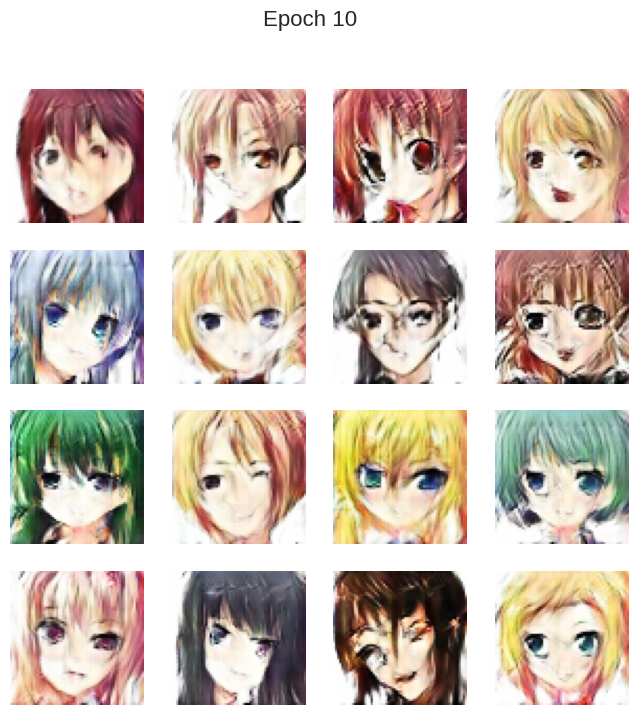

Epoch  15/50 | Gen Loss: 5.1482 | Disc Loss: 0.2068 | Time: 152.06s
Epoch  20/50 | Gen Loss: 5.2113 | Disc Loss: 0.2595 | Time: 152.66s


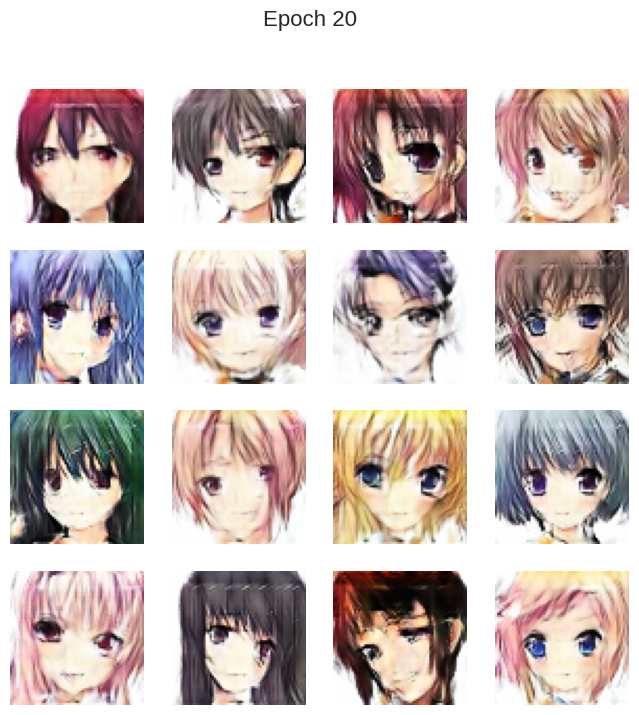

Epoch  25/50 | Gen Loss: 5.9215 | Disc Loss: 0.1492 | Time: 151.97s
Epoch  30/50 | Gen Loss: 7.3157 | Disc Loss: 0.1146 | Time: 151.48s


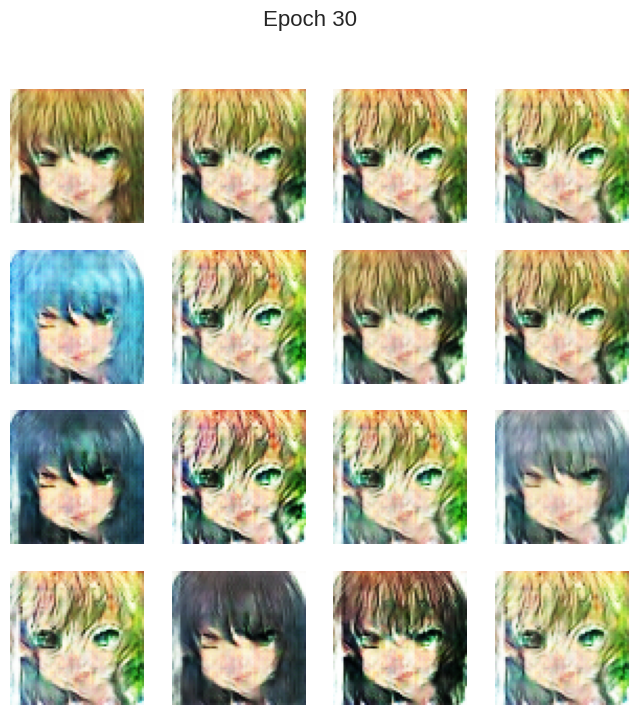

Epoch  35/50 | Gen Loss: 7.0592 | Disc Loss: 0.1025 | Time: 150.84s
Epoch  40/50 | Gen Loss: 7.0161 | Disc Loss: 0.1112 | Time: 149.90s


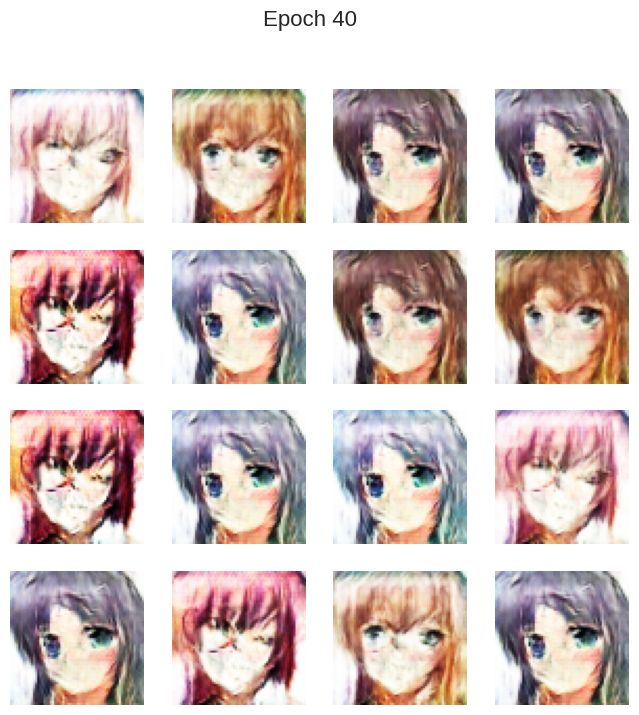

Epoch  45/50 | Gen Loss: 7.4128 | Disc Loss: 0.0992 | Time: 150.80s
Epoch  50/50 | Gen Loss: 7.3345 | Disc Loss: 0.0745 | Time: 151.04s


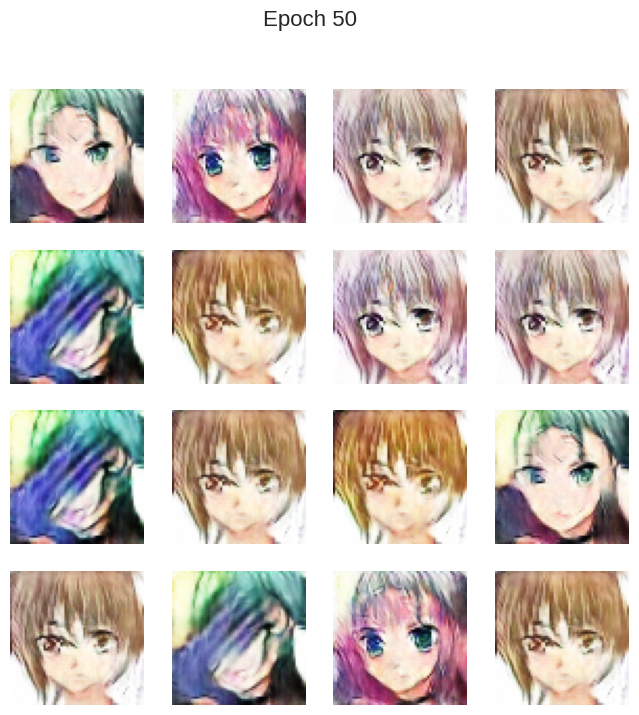

In [43]:
EPOCHS = 50

history = {'gen_loss': [], 'disc_loss': []}

print("Training the GAN...")

for epoch in range(EPOCHS):
  start_time = time.time()
  epoch_gen_loss = []
  epoch_disc_loss = []

  for batch in dataset:
    gen_loss, disc_loss = train_step(batch)
    epoch_gen_loss.append(gen_loss.numpy())
    epoch_disc_loss.append(disc_loss.numpy())

  # Record history
  avg_gen_loss = np.mean(epoch_gen_loss)
  avg_disc_loss = np.mean(epoch_disc_loss)
  history['gen_loss'].append(avg_gen_loss)
  history['disc_loss'].append(avg_disc_loss)

  elapsed_time = time.time() - start_time

  if (epoch + 1) % 5 == 0 or epoch == 0:
    print(f"Epoch {epoch+1:3d}/{EPOCHS} | Gen Loss: {avg_gen_loss:.4f} | Disc Loss: {avg_disc_loss:.4f} | Time: {elapsed_time:.2f}s")

  # Generate and save images every 10 epochs
  if (epoch + 1) % 10 == 0:
    generate_and_train_images(generator, epoch + 1, SEED_NOISE)

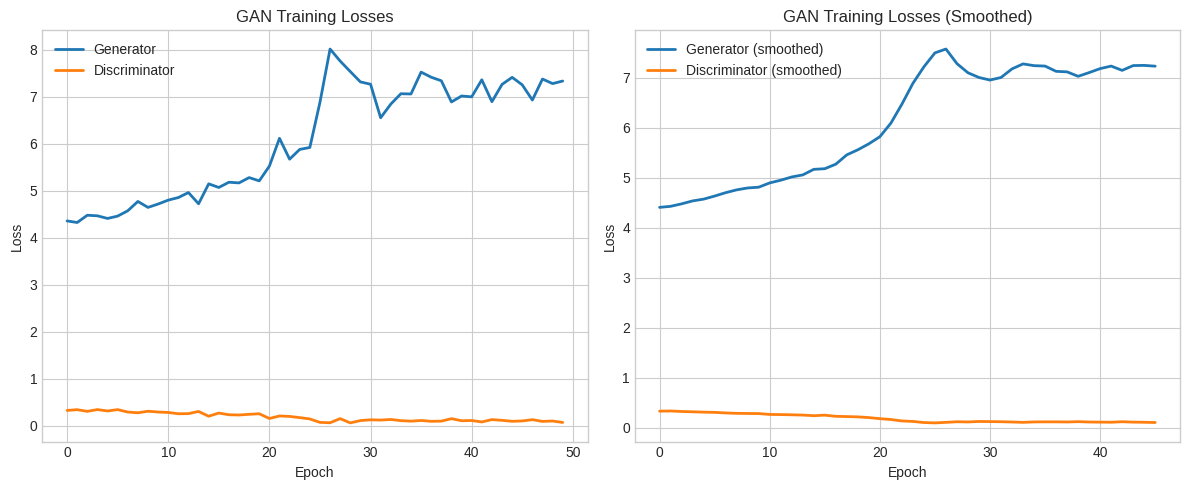

In [44]:
# Plot training curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['gen_loss'], label='Generator', linewidth=2)
plt.plot(history['disc_loss'], label='Discriminator', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GAN Training Losses')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
# Moving average for smoother visualization
window = 5
gen_smooth = np.convolve(history['gen_loss'], np.ones(window)/window, mode='valid')
disc_smooth = np.convolve(history['disc_loss'], np.ones(window)/window, mode='valid')
plt.plot(gen_smooth, label='Generator (smoothed)', linewidth=2)
plt.plot(disc_smooth, label='Discriminator (smoothed)', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GAN Training Losses (Smoothed)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

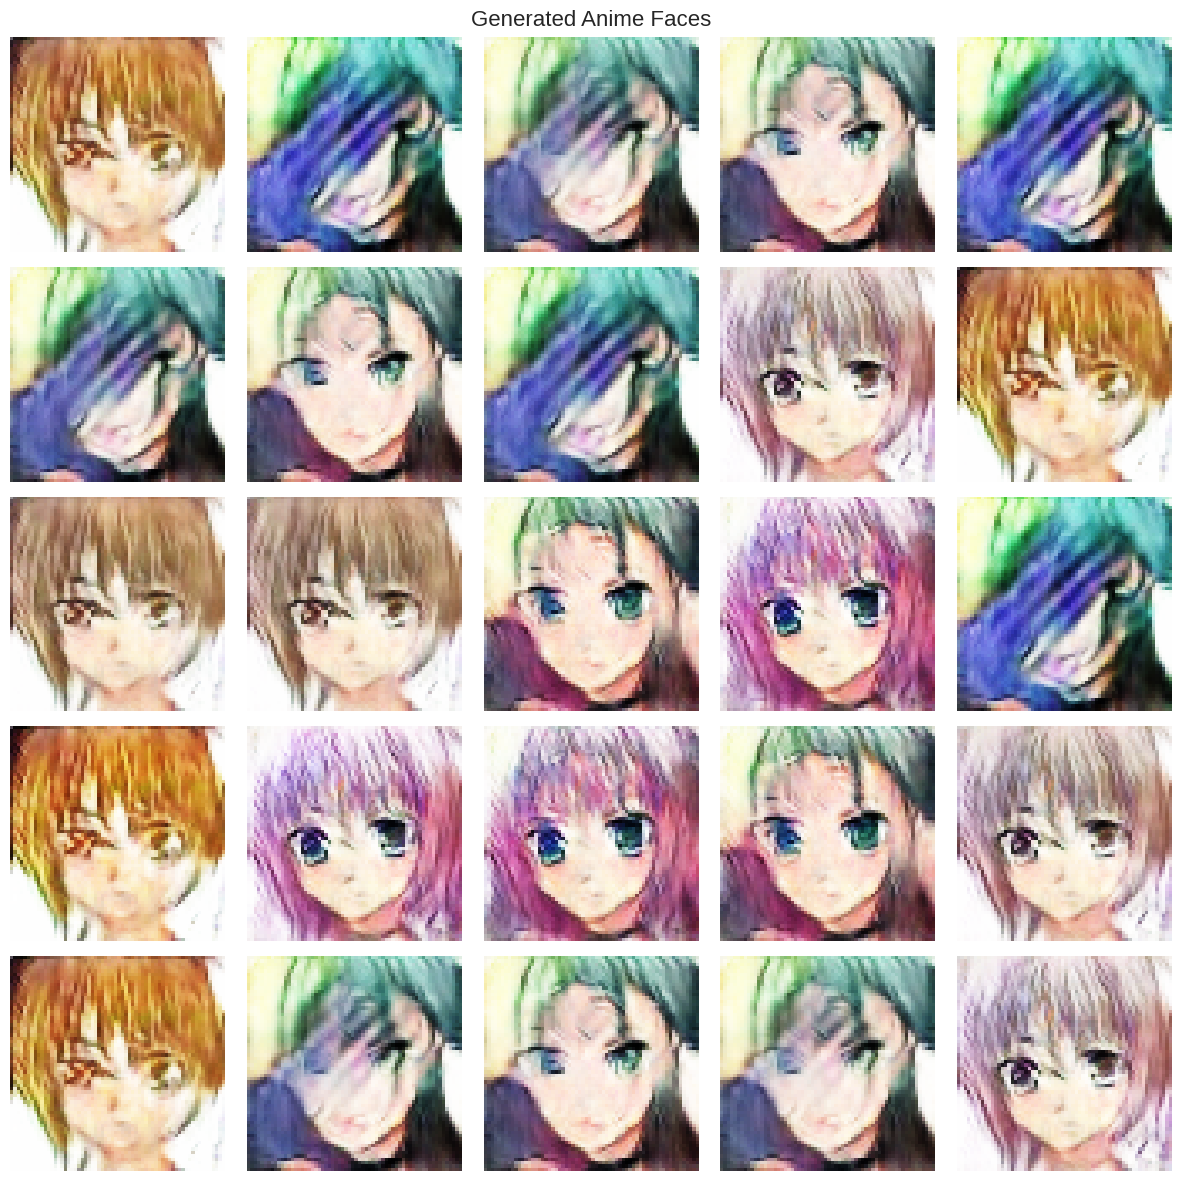

In [45]:
# Generate multiple samples
n_samples = 25
random_noise = tf.random.normal([n_samples, LATENT_DIM])

generated = generator(random_noise, training=False)

fig, axes = plt.subplots(5, 5, figsize=(12, 12))

for i, ax in enumerate(axes.flatten()):
    img = (generated[i].numpy() + 1) / 2
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.axis('off')

plt.suptitle('Generated Anime Faces', fontsize=16)
plt.tight_layout()
plt.show()

Latent Space Interpolation

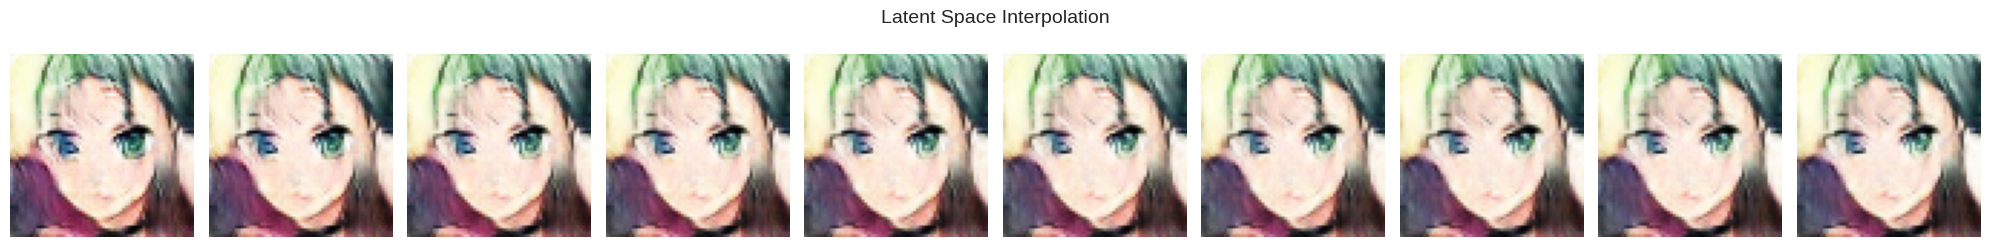

In [46]:
def interpolate_latent(generator, z1, z2, n_steps=10):
    """Interpolate between two latent vectors"""
    ratios = np.linspace(0, 1, n_steps)
    vectors = [(1 - ratio) * z1 + ratio * z2 for ratio in ratios]
    vectors = tf.stack(vectors)

    generated = generator(vectors, training=False)
    return generated

# Two random latent points
z1 = tf.random.normal([1, LATENT_DIM])
z2 = tf.random.normal([1, LATENT_DIM])

interpolated = interpolate_latent(generator, z1[0], z2[0], n_steps=10)

fig, axes = plt.subplots(1, 10, figsize=(20, 2.5))

for i, ax in enumerate(axes):
    img = (interpolated[i].numpy() + 1) / 2
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.axis('off')

plt.suptitle('Latent Space Interpolation', fontsize=14)
plt.tight_layout()
plt.show()


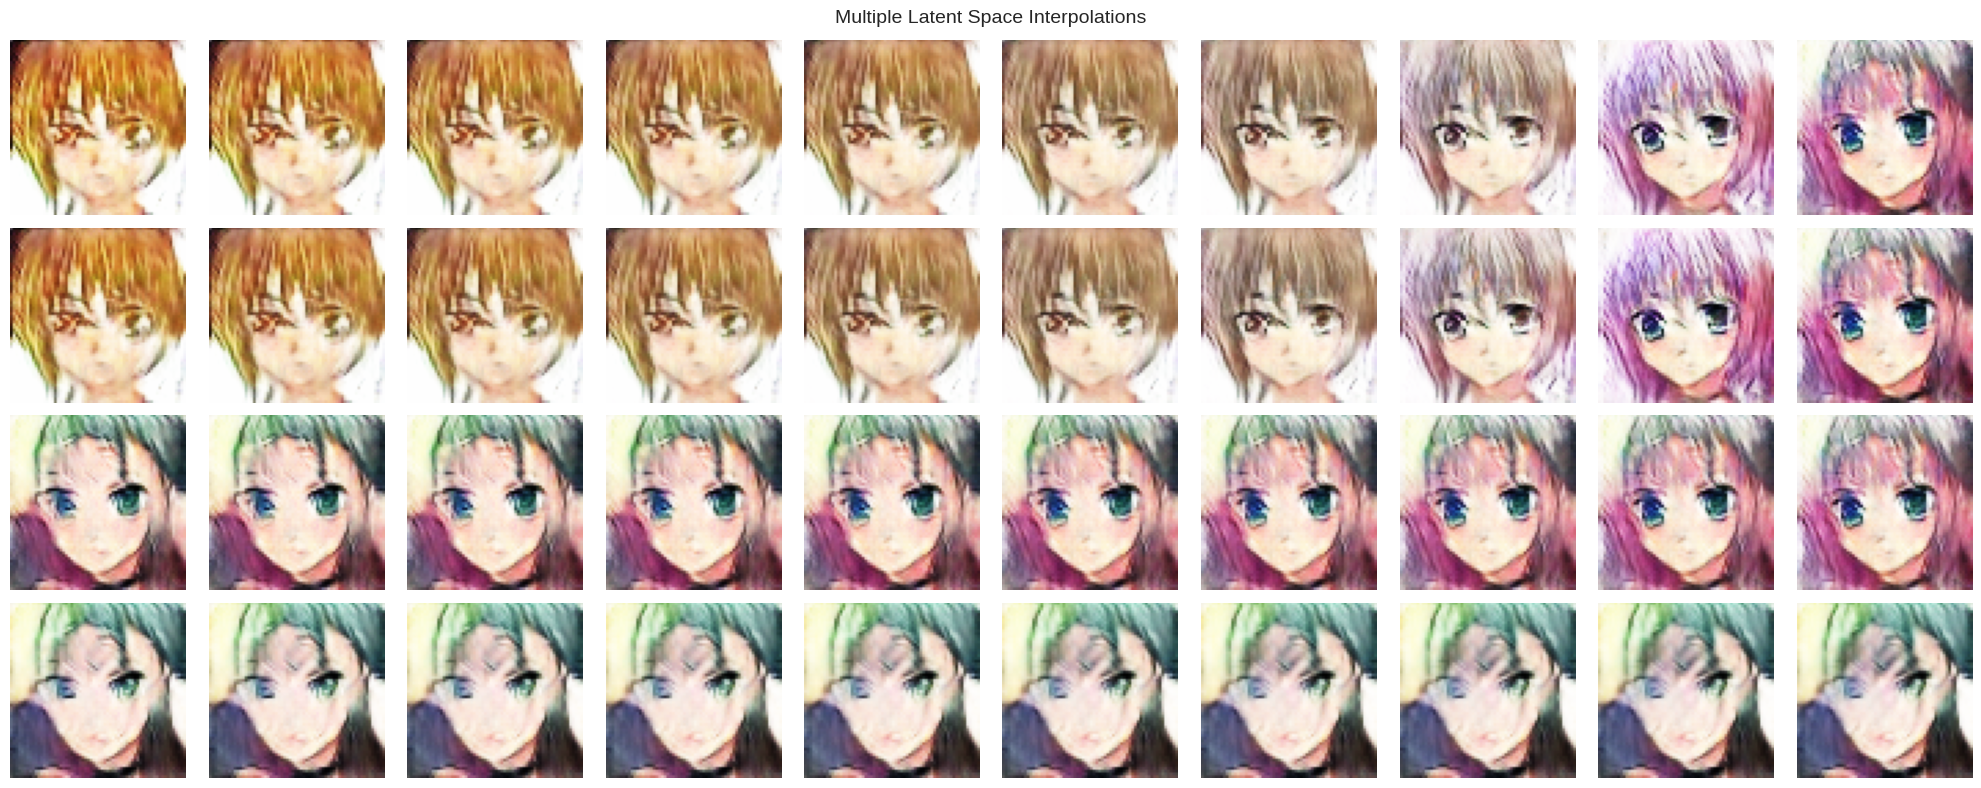

In [47]:
# Multiple interpolations
fig, axes = plt.subplots(4, 10, figsize=(20, 8))

for row in range(4):
    z1 = tf.random.normal([1, LATENT_DIM])
    z2 = tf.random.normal([1, LATENT_DIM])
    interpolated = interpolate_latent(generator, z1[0], z2[0], n_steps=10)

    for col in range(10):
        img = (interpolated[col].numpy() + 1) / 2
        img = np.clip(img, 0, 1)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')

plt.suptitle('Multiple Latent Space Interpolations', fontsize=14)
plt.tight_layout()
plt.show()

In [48]:
from google.colab import drive

drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/100-days-of-ml/phase-3-deep-learning/day-58-gans'
os.makedirs(save_path, exist_ok=True)

generator.save(f'{save_path}/anime_generator.keras')
discriminator.save(f'{save_path}/anime_discriminator.keras')

print(f"Saved to: {save_path}")
print("\nTo generate new faces:")
print("  generator = keras.models.load_model('anime_generator.keras')")
print("  noise = tf.random.normal([1, 100])")
print("  face = generator(noise)")

Mounted at /content/drive
Saved to: /content/drive/MyDrive/100-days-of-ml/phase-3-deep-learning/day-58-gans

To generate new faces:
  generator = keras.models.load_model('anime_generator.keras')
  noise = tf.random.normal([1, 100])
  face = generator(noise)
